# Analyse des facteurs influençant la souscription à une offre bancaire suite à une campagne de téléprospection

### Problématique : Quels sont les profils de clients les plus susceptibles de souscrire à une offre bancaire après un appel téléphonique ?

# analyse de données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('donnees_marketing_banque.csv', sep=';')

La ligne de code lit un fichier CSV nommé donnees_marketing_banque.csv en utilisant la bibliothèque Pandas. Comme les valeurs du fichier sont séparées par des points-virgules (;), le paramètre sep=';' est utilisé pour bien structurer les colonnes. Le contenu du fichier est ensuite stocké dans une variable appelée df, qui devient un DataFrame, c’est-à-dire une table de données facilement exploitable avec Pandas.

In [3]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,id1,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,id2,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,id3,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,id4,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,id5,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198,1,-1,0,unknown,no


La commande df.head() affiche les 5 premières lignes du DataFrame df.

Cela permet de visualiser un aperçu des données : tu verras les premières entrées du tableau ainsi que les noms des colonnes, ce qui est très utile pour comprendre rapidement la structure du jeu de données (types de variables, format, éventuelles valeurs manquantes, etc.).

In [4]:
type(df)

pandas.core.frame.DataFrame

L'affichage du type de df avec la commande type(df) indique qu'il s'agit d'un DataFrame, une structure de données tabulaire à deux dimensions fournie par la bibliothèque Pandas, idéale pour l’analyse et la manipulation de données.

In [5]:
df.tail()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,id45207,51,technician,married,tertiary,no,825.0,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,id45208,71,retired,divorced,primary,no,1729.0,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,id45209,72,retired,married,secondary,no,5715.0,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,id45210,57,blue-collar,married,secondary,no,668.0,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,id45211,37,entrepreneur,married,secondary,no,2971.0,no,no,cellular,17,nov,361,2,188,11,other,no


La commande df.tail() affiche les 5 dernières lignes du DataFrame, permettant de visualiser la fin du jeu de données.

In [6]:
df.columns

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

id : identifiant unique du client.

age : âge du client.

job : métier du client (ex : management, technician, etc.).

marital : statut marital (single, married, divorced).

education : niveau d'éducation (primary, secondary, tertiary, unknown).

default : le client a-t-il un défaut de crédit ? (yes/no).

balance : solde moyen annuel sur le compte bancaire.

housing : a-t-il un prêt immobilier ? (yes/no).

loan : a-t-il un prêt personnel ? (yes/no).

contact : type de contact utilisé pour la campagne (cellular, telephone, unknown).

day : jour du mois où le contact a eu lieu.

month : mois du contact.

duration : durée du dernier contact (en secondes).

campaign : nombre de contacts effectués durant cette campagne.

pdays : nombre de jours depuis le dernier contact (−1 signifie jamais contacté).

previous : nombre de contacts lors de campagnes précédentes.

poutcome : résultat de la précédente campagne marketing.

y : le client a-t-il souscrit à un dépôt à terme ? (target : yes/no).

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         45211 non-null  object 
 1   age        45211 non-null  int64  
 2   job        45211 non-null  object 
 3   marital    45211 non-null  object 
 4   education  45211 non-null  object 
 5   default    45211 non-null  object 
 6   balance    45206 non-null  float64
 7   housing    45211 non-null  object 
 8   loan       45211 non-null  object 
 9   contact    45211 non-null  object 
 10  day        45211 non-null  int64  
 11  month      45211 non-null  object 
 12  duration   45211 non-null  int64  
 13  campaign   45211 non-null  int64  
 14  pdays      45211 non-null  int64  
 15  previous   45211 non-null  int64  
 16  poutcome   45211 non-null  object 
 17  y          45211 non-null  object 
dtypes: float64(1), int64(6), object(11)
memory usage: 6.2+ MB


Le dataset contient 45 211 lignes et 18 colonnes. Les colonnes sont de types variés : certaines sont de type entier (int64), d'autres de type flottant (float64) ou texte (object), ce qui permet de distinguer les variables numériques des variables qualitatives.

In [8]:
df.describe(include='all')

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211,45211.000000,45211,45211,45211,45211,45206.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,45211,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,id1,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,1,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,NaN,40.931477,NaN,NaN,NaN,NaN,1362.403707,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,NaN,10.623372,NaN,NaN,NaN,NaN,3044.906741,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,NaN,10.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,NaN,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,NaN,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,NaN,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


La commande df.describe(include='all') permet d’afficher un résumé statistique complet du DataFrame df, en incluant toutes les colonnes, qu’elles soient numériques ou catégorielles.

Ce que cela affiche :
| Pour les colonnes numériques (int, float) :
| - count : nombre de valeurs non nulles
| - mean : moyenne
| - std : écart-type
| - min : valeur minimale
| - 25%, 50%, 75% : quartiles
| - max : valeur maximale

| Pour les colonnes catégorielles (object) :
| - count : nombre de valeurs non nulles
| - unique : nombre de modalités différentes
| - top : modalité la plus fréquente
| - freq : fréquence de cette modalité

Exemple :
Pour une colonne comme job (texte), tu verras par exemple :

count : 45211

unique : 12

top : "blue-collar"

freq : 9732

Cela permet de comprendre rapidement la distribution, la diversité et la qualité des données dans chaque colonne.

In [9]:
df["education"].unique()

array(['tertiary', 'secondary', 'unknown', 'primary'], dtype=object)

La colonne "education" contient des données qualitatives avec 4 catégories distinctes : 'tertiary', 'secondary', 'primary' et 'unknown'. Ces modalités représentent respectivement les niveaux d’éducation supérieur, secondaire, primaire, et les cas où le niveau d’éducation n’est pas renseigné (unknown). Cette variable peut être utile pour analyser l’influence du niveau d’études sur le comportement des clients.

<Axes: xlabel='education'>

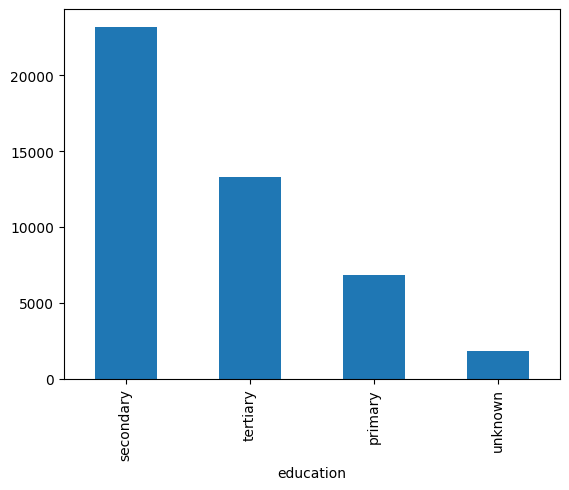

In [10]:
df["education"].value_counts().plot(kind='bar')

Analyse visuelle de la variable "education" :
Secondary (études secondaires) est largement majoritaire, avec plus de 22 000 individus. C’est la modalité dominante dans l’échantillon.

Tertiary (études supérieures) arrive en seconde position, avec environ 13 000 individus. Cela montre qu’une part importante de la population a un niveau universitaire ou équivalent.

Primary (études primaires) représente un groupe nettement plus réduit, autour de 7 000 individus.

Enfin, Unknown est la modalité la moins fréquente, avec environ 2 000 individus. Elle regroupe les cas où le niveau d’éducation n’a pas été précisé.

Conclusion :
Ce graphique met en évidence une population plutôt instruite, majoritairement issue de l’enseignement secondaire et supérieur. La part relativement faible de modalités "unknown" indique une bonne qualité de données pour cette variable. Ce type de répartition peut influencer l’interprétation d’autres variables, comme la souscription à un produit bancaire ou la réponse à une campagne marketing.











## néttoyage des données

In [11]:
# vaeurs manquantes
df.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      5
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Recherche des valeurs manquantes :
L’analyse des valeurs manquantes montre que seule la colonne balance contient des données manquantes, avec 5 valeurs nulles. Toutes les autres colonnes du jeu de données sont complètes, ce qui signifie qu’elles ne contiennent aucune valeur manquante.

Conclusion :
Le dataset est globalement de bonne qualité, avec très peu de données manquantes. La colonne balance, qui représente probablement le solde du compte bancaire, nécessitera un traitement ciblé (imputation, suppression ou autre méthode) pour gérer les 5 valeurs absentes.


Étant donné que seules 5 valeurs sont manquantes dans la colonne balance sur un total de 45 211 lignes, ce nombre est négligeable. Nous choisissons donc de les ignorer afin de ne pas complexifier inutilement le traitement des données. Ce choix est justifié par le fait que ces valeurs représentent moins de 0,01 % du dataset, ce qui a un impact minimal sur l’analyse globale.








In [12]:
mean = df["balance"].mean()
mean

1362.4037074724595

In [13]:
df_remplace_mean = df.fillna(mean)

df_remplace_mean.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Lorsqu’il y a des valeurs manquantes dans une colonne numérique, il est possible de les remplacer par la moyenne de cette colonne afin de ne pas perdre d’informations. Dans ce cas, on utilise la fonction fillna(mean) pour créer un nouveau DataFrame df_remplace_mean où les valeurs manquantes ont été remplacées par la moyenne. La commande df_remplace_mean.isnull().sum() permet ensuite de vérifier qu’il n’y a plus de valeurs manquantes dans le dataset. C’est une méthode simple et efficace lorsqu’il y a très peu de données manquantes, comme ici avec seulement 5 valeurs.

In [14]:
df_sup = df.drop(["month", "day"], axis=1)
df_sup

,id,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,y
0,id1,58,management,married,tertiary,no,2143.0,yes,no,unknown,261,1,-1,0,unknown,no
1,id2,44,technician,single,secondary,no,29.0,yes,no,unknown,151,1,-1,0,unknown,no
2,id3,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,76,1,-1,0,unknown,no
3,id4,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,92,1,-1,0,unknown,no
4,id5,33,unknown,single,unknown,no,1.0,no,no,unknown,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,id45207,51,technician,married,tertiary,no,825.0,no,no,cellular,977,3,-1,0,unknown,yes
45207,id45208,71,retired,divorced,primary,no,1729.0,no,no,cellular,456,2,-1,0,unknown,yes
45208,id45209,72,retired,married,secondary,no,5715.0,no,no,cellular,1127,5,184,3,success,yes
45209,id45210,57,blue-collar,married,secondary,no,668.0,no,no,telephone,508,4,-1,0,unknown,no


La commande df.drop(["month", "day"], axis=1) permet de supprimer les colonnes month et day du DataFrame df. Ces colonnes sont retirées horizontalement (c’est-à-dire des colonnes, pas des lignes), grâce au paramètre axis=1.
Le résultat est stocké dans un nouveau DataFrame appelé df_sup, qui contient toutes les colonnes d'origine sauf month et day.
Cette opération est utile si ces variables sont jugées non pertinentes pour l’analyse ou si l’on souhaite simplifier le dataset.

In [15]:
df_select = df[["age", "loan", "education"]]
df_select

,age,loan,education
0,58,no,tertiary
1,44,no,secondary
2,33,yes,secondary
3,47,no,unknown
4,33,no,unknown
...,...,...,...
45206,51,no,tertiary
45207,71,no,primary
45208,72,no,secondary
45209,57,no,secondary


La commande df[["age", "loan", "education"]] permet de sélectionner uniquement trois colonnes du DataFrame : age, loan et education. Le résultat est stocké dans un nouveau DataFrame nommé df_select.
Ce sous-ensemble de données peut être utilisé pour se concentrer sur des variables spécifiques, par exemple pour une analyse ciblée du lien entre l'âge, le niveau d’éducation et la présence d’un prêt personnel (loan).

In [16]:
# premières approches
(df["age"] >= 18) & (df["education"] == "secondary")
age_sup= df[(df["age"] >= 18) & (df["education"] == "secondary")]
age_sup

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
1,id2,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,id3,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
9,id10,43,technician,single,secondary,no,NaN,yes,no,unknown,5,may,55,1,-1,0,unknown,no
10,id11,41,admin.,divorced,secondary,no,270.0,yes,no,unknown,5,may,222,1,-1,0,unknown,no
11,id12,29,admin.,single,secondary,no,390.0,yes,no,unknown,5,may,137,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45204,id45205,73,retired,married,secondary,no,2850.0,no,no,cellular,17,nov,300,1,40,8,failure,yes
45205,id45206,25,technician,single,secondary,no,505.0,no,yes,cellular,17,nov,386,2,-1,0,unknown,yes
45208,id45209,72,retired,married,secondary,no,5715.0,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,id45210,57,blue-collar,married,secondary,no,668.0,no,no,telephone,17,nov,508,4,-1,0,unknown,no


Le filtrage effectué sélectionne uniquement les individus âgés de 18 ans ou plus et ayant un niveau d’éducation "secondary" (études secondaires). Le résultat est enregistré dans un nouveau sous-ensemble de données. Cette opération permet de se concentrer sur une population bien définie : les adultes ayant suivi un enseignement secondaire, ce qui peut être pertinent pour une analyse ciblée, notamment en marketing ou en segmentation de clientèle.

In [17]:
df["tranche_d'age"] = np.nan

Une nouvelle variable "tranche_d'age" est créée afin de stocker des informations sur les tranches d’âge des individus (par exemple : jeunes, adultes, seniors).
Elle est pour l’instant vide (remplie de valeurs manquantes), en attendant d’être renseignée par une classification ultérieure (par tranche d’âge définie selon des seuils).

In [18]:
df["tranche_d'age"][df["age"] < 18] = "<18"
df["tranche_d'age"][(df["age"] >= 18) & (df["age"] < 25)] = "18-25"
df["tranche_d'age"][(df["age"] >= 25) & (df["age"] < 50)] = "25-50"
df["tranche_d'age"][(df["age"] >= 50)] = ">=50"

/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7704/2569273121.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tranche_d'age"][df["age"] < 18] = "<18"


La colonne tranche_d'age, précédemment créée, est maintenant remplie en fonction de l’âge de chaque individu, selon des catégories définies :

Les personnes de moins de 18 ans sont classées dans la tranche "<18".

Celles ayant entre 18 et 24 ans sont regroupées dans "18-25".

Les individus âgés de 25 à 49 ans sont assignés à la tranche "25-50".

Enfin, ceux de 50 ans ou plus sont placés dans la catégorie ">=50".

Objectif :
Cette classification permet de transformer la variable continue age en variable catégorielle, ce qui facilite :

l’analyse comparative entre groupes d’âge,

la visualisation (graphiques en barres),

et éventuellement, des modèles prédictifs avec variables discrètes.

In [19]:
df["tranche_d'age"].unique()

array(['>=50', '25-50', '<18', '18-25'], dtype=object)

La commande df["tranche_d'age"].unique() permet d’afficher toutes les valeurs uniques présentes dans la colonne tranche_d'age, c’est-à-dire les différentes tranches d’âge utilisées dans le dataset.

<Axes: xlabel="tranche_d'age">

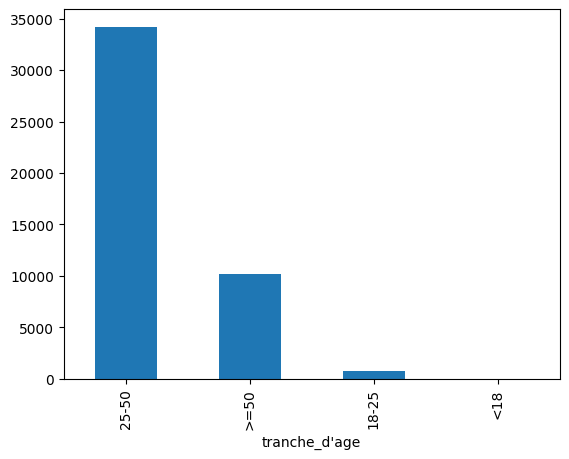

In [20]:
df["tranche_d'age"].value_counts().plot(kind='bar')

Répartition des tranches d’âge dans le dataset :
La grande majorité des individus appartient à la tranche "25-50", avec environ 34 000 personnes, ce qui en fait le groupe le plus représenté.

La tranche ">=50" regroupe un peu plus de 10 000 personnes, représentant une part significative mais bien moindre.

La tranche "18-25" est très faiblement représentée, avec moins de 2 000 individus.

La tranche "<18" est quasiment absente du graphique, ce qui indique que très peu de clients ont moins de 18 ans (voire aucun).

Conclusion :
Ce graphique montre que le dataset est principalement composé d’adultes actifs âgés de 25 à 50 ans, ce qui est cohérent avec une base de données marketing bancaire. Les tranches plus jeunes sont très minoritaires, ce qui pourrait limiter certaines analyses ciblant cette population.











<Axes: >

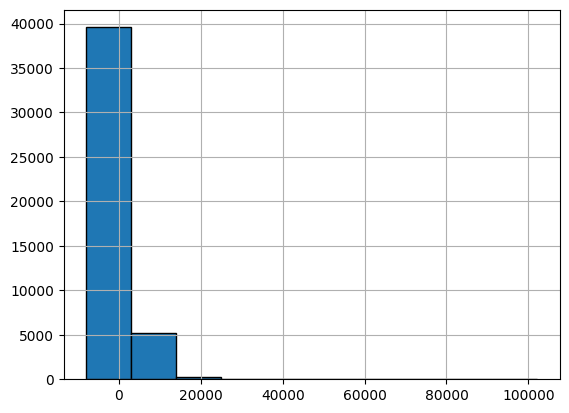

In [21]:
df["balance"].hist(bins=10, edgecolor='black')

 Distribution de la variable balance (solde du compte bancaire) :
La distribution est très asymétrique à droite (distribution étalée vers les grandes valeurs).

La grande majorité des individus ont un solde bancaire faible ou proche de zéro, concentré dans les premières barres à gauche de l’histogramme.

Quelques individus ont des soldes très élevés, jusqu’à 100 000, mais ils sont extrêmement rares (valeurs extrêmes ou atypiques).

Cette distribution suggère la présence d’outliers (valeurs extrêmes) qui pourraient influencer certaines analyses statistiques (comme la moyenne).

Conclusion :
La variable balance présente une forte concentration de petits soldes et quelques valeurs extrêmes élevées. Cela peut nécessiter :

un traitement des outliers (par exemple, normalisation, logarithme),

ou l’utilisation de la médiane plutôt que la moyenne pour résumer la tendance centrale.



<Axes: xlabel="tranche_d'age">

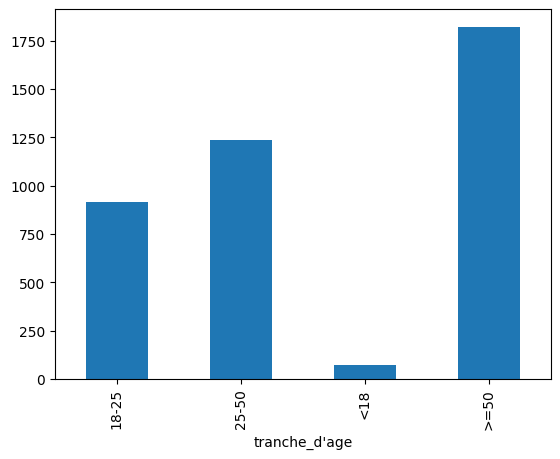

In [22]:
df.groupby("tranche_d'age")["balance"].mean().plot(kind='bar')

Répartition des individus ayant un prêt personnel (loan = yes) selon la tranche d’âge :
Le graphique montre la distribution des personnes ayant un prêt en fonction des tranches d’âge :

La catégorie ">=50" est la plus représentée parmi les emprunteurs, avec environ 1 800 individus.

Elle est suivie par la tranche "25-50", avec environ 1 250 individus.

Les jeunes adultes "18-25" sont également présents mais en nombre plus réduit (environ 900).

Enfin, les individus de la tranche "<18" sont très peu nombreux à avoir un prêt, ce qui est cohérent avec les conditions d’octroi de crédit.

Conclusion :
Les prêts personnels concernent majoritairement les adultes de plus de 25 ans, et tout particulièrement les personnes de 50 ans et plus. Cela peut s’expliquer par une stabilité financière plus importante avec l’âge, ou des besoins spécifiques (travaux, projets personnels, etc.). Ce type de visualisation permet de cibler les profils les plus enclins à contracter un prêt.

<Axes: xlabel='education'>

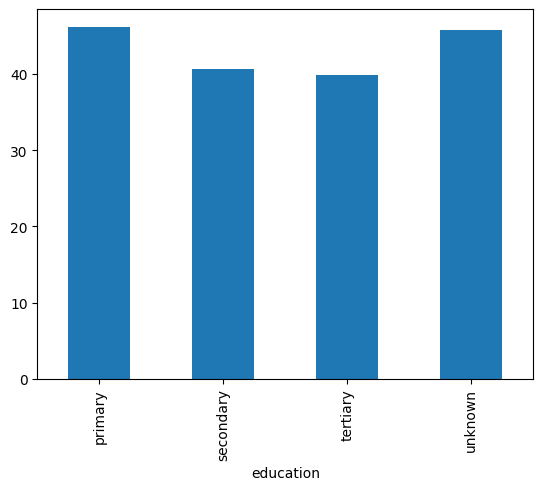

In [23]:
df_sup25 = df[df["age"] > 25]

df_sup25.groupby("education")["age"].mean().plot(kind='bar')

Taux de souscription (ou comportement) selon le niveau d’éducation :
Le graphique montre que les individus ayant un niveau primary ou unknown présentent un taux plus élevé (environ 47%) que ceux ayant un niveau secondary ou tertiary (autour de 40%).

 Conclusion :
Cette tendance, contre-intuitive, suggère que les personnes avec un niveau d’éducation moins élevé ou non renseigné seraient plus enclines à répondre positivement (ex. : souscrire à une offre bancaire). Cela peut s’expliquer par différents facteurs socio-économiques ou par un ciblage spécifique. Il serait pertinent d'explorer ces résultats en croisant avec d'autres variables (âge, solde, contact, etc.) pour affiner l’interprétation.



# Visualisation

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns 

In [25]:
df.dtypes

id                object
age                int64
job               object
marital           object
education         object
default           object
balance          float64
housing           object
loan              object
contact           object
day                int64
month             object
duration           int64
campaign           int64
pdays              int64
previous           int64
poutcome          object
y                 object
tranche_d'age     object
dtype: object

In [26]:
df_majeur = df[df["age"] >= 18]
df_majeur.describe()


,age,balance,day,duration,campaign,pdays,previous
count,45203.000000,45198.000000,45203.000000,45203.000000,45203.000000,45203.000000,45203.000000
mean,40.936133,1362.631997,15.808331,258.168816,2.764153,40.205119,0.580426
std,10.618494,3045.126997,8.321971,257.548471,3.098206,100.136106,2.303632
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,449.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Résumé des variables numériques (adultes uniquement) :
age :

Moyenne : 40,9 ans

Écart-type : 10,6

Minimum : 18 / Maximum : 95 ans

Distribution centrée autour de 39 ans (médiane)

balance (solde bancaire) :

Moyenne : 1 362 €

Médiane : 449 € → montre une asymétrie (valeurs extrêmes élevées)

Valeur min : -8 019 € (découvert)

Valeur max : 102 127 € (extrêmement élevée)

day (jour du dernier contact) :

Allant de 1 à 31, avec une médiane à 16

Représente un jour du mois (pas de valeur aberrante)

duration (durée de l’appel en secondes) :

Moyenne : 258 secondes (~4 minutes)

Max : 4 918 sec (~1h22), min : 0 → certains appels n’ont pas été aboutis

campaign (nombre de contacts dans la campagne actuelle) :

Moyenne : 2,76 contacts

Extrême max : 63 contacts → comportement anormal ou client difficile à joindre

pdays (jours depuis dernier contact précédent) :

Valeur fréquente : -1 → signifie "jamais contacté auparavant"

Moyenne élevée à cause de quelques valeurs très grandes (max : 871)

previous (nombre de contacts précédents) :

Moyenne faible (0,58), mais max à 275 → très grande dispersion due à quelques cas extrêmes

Le dataset contient des valeurs extrêmes dans plusieurs variables (balance, duration, campaign, previous), ce qui justifie une attention particulière avant toute modélisation (standardisation, traitement des outliers). L’analyse révèle une population majoritairement adulte d'âge moyen, avec une forte variabilité dans les comportements de contact et les situations bancaires.


### Visualisation des variables quantitatives univariées

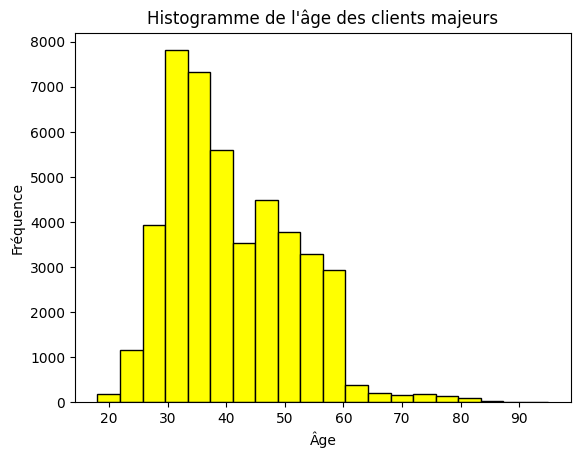

In [27]:
# histogramme de la variable age
plt.hist(df_majeur["age"], bins=20, edgecolor="black", color="yellow")
plt.Figure(figsize=(10, 6))
plt.title("Histogramme de l'âge des clients majeurs")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.show()


Analyse de la distribution des âges :
La plupart des clients majeurs ont entre 30 et 40 ans, avec un pic autour de 35 ans. C’est la tranche d’âge la plus représentée dans la base.

La distribution est asymétrique à droite (queue longue vers les âges plus élevés), ce qui signifie que les clients plus âgés (au-delà de 60 ans) sont beaucoup moins nombreux.

Très peu de clients ont moins de 25 ans ou plus de 70 ans.

L’âge maximum observé dépasse 90 ans, mais ces cas sont extrêmement rares.

 Conclusion :
La population de clients majeurs est essentiellement composée d’adultes en âge actif, avec une forte concentration autour de 30 à 50 ans. Ce profil est typique des cibles commerciales en banque ou assurance. La faible représentation des jeunes adultes et des seniors pourrait influencer la segmentation et les campagnes marketing.

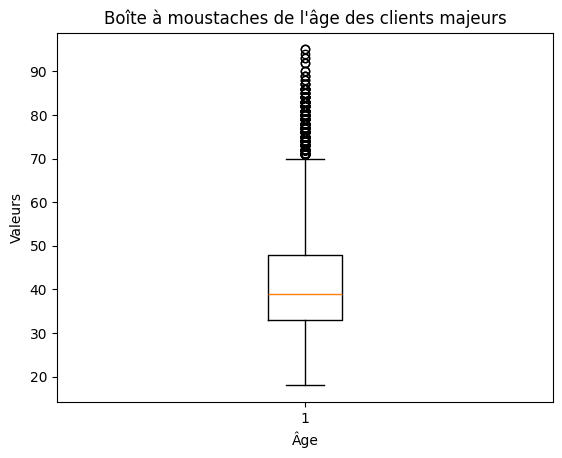

In [28]:
plt.boxplot(df_majeur["age"])
plt.title("Boîte à moustaches de l'âge des clients majeurs")
plt.xlabel("Âge")
plt.ylabel("Valeurs")
plt.show()

Interprétation du graphique :
La boîte centrale représente les 50 % des valeurs centrales :

Le trait à l’intérieur est la médiane (~39 ans).

Les bords de la boîte correspondent au 1er quartile (~33 ans) et au 3e quartile (~48 ans).

Les moustaches s’étendent jusqu’à environ 70 ans, ce qui indique la plage des valeurs "normales".

Les points au-dessus de 70 ans sont des valeurs atypiques (outliers) : ce sont des clients beaucoup plus âgés que la moyenne, identifiés séparément.

L’âge minimum est de 18 ans, ce qui est cohérent avec le filtre appliqué (age >= 18).

Conclusion :
La majorité des clients a entre 33 et 48 ans, avec une médiane à 39 ans, ce qui confirme une population centrée autour de l’âge actif.
Les individus âgés de plus de 70 ans sont considérés comme des valeurs extrêmes, peu fréquentes, mais visibles dans les données.
Ce type de graphique est utile pour détecter les variations, la symétrie et les valeurs atypiques au sein d’une variable continue.

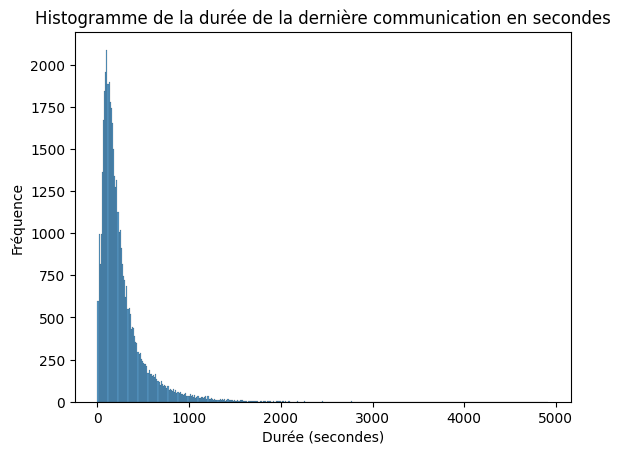

In [29]:
# Histogramme durée de la dernière communication en seconde 

sns.histplot(df["duration"])
plt.title("Histogramme de la durée de la dernière communication en secondes")
plt.xlabel("Durée (secondes)")
plt.ylabel("Fréquence")
plt.show()


Interprétation de la variable duration :
La grande majorité des appels durent entre 0 et 300 secondes (0 à 5 minutes), avec un pic de fréquence autour de 100 à 150 secondes.

La distribution est fortement asymétrique à droite, c’est-à-dire qu’il y a beaucoup de petites durées et très peu de longues communications.

Des appels de plus de 1 000 secondes (environ 17 minutes) existent, mais ils sont très rares.

Des appels de durée nulle sont également présents, ce qui peut indiquer des échecs d’appel ou des refus immédiats.

 Conclusion :
La durée des appels suit une distribution typique de type exponentielle, où les appels courts sont la norme, et les appels très longs sont exceptionnels. Cette variable est souvent un bon indicateur de l'engagement du client : plus l'appel est long, plus le client est potentiellement intéressé par l'offre.

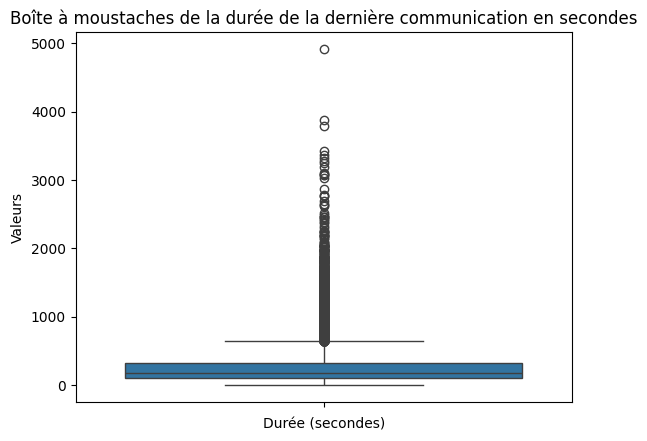

In [30]:
sns.boxplot(df_majeur["duration"])
plt.title("Boîte à moustaches de la durée de la dernière communication en secondes")
plt.xlabel("Durée (secondes)")
plt.ylabel("Valeurs")
plt.show()


 Interprétation :
La boîte centrale montre que la majorité des appels durent entre environ 100 et 300 secondes.

La médiane (ligne dans la boîte) est située autour de 180 secondes, ce qui indique que la moitié des appels durent moins de 3 minutes.

Les moustaches s’étendent jusqu’à environ 600-700 secondes, au-delà desquelles les valeurs sont considérées comme atypiques (outliers).

De très nombreux points isolés au-dessus de la boîte (jusqu’à près de 5 000 secondes) représentent des appels exceptionnellement longs, qui sont statistiquement rares.

La présence d’un grand nombre d’outliers visuellement montre une forte dispersion et une asymétrie à droite de la distribution.

Conclusion :
La durée des communications varie beaucoup, avec une forte concentration d’appels courts et un petit nombre d’appels très longs.
Ces valeurs extrêmes doivent être prises en compte avec prudence dans les analyses, car elles peuvent influencer la moyenne ou fausser certains modèles statistiques.
Il peut être pertinent de les traiter à part ou de les transformer (ex. : logarithme) pour une analyse plus robuste.

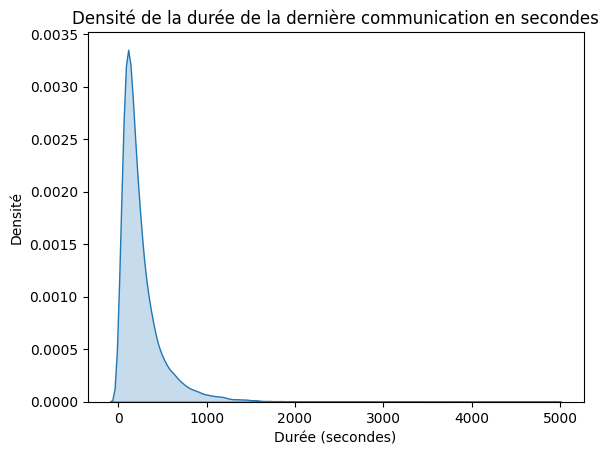

In [31]:
sns.kdeplot(df["duration"], fill=True)
plt.title("Densité de la durée de la dernière communication en secondes")
plt.xlabel("Durée (secondes)")
plt.ylabel("Densité")
plt.show()

 Interprétation de la courbe de densité :
La distribution est très fortement asymétrique à droite (right-skewed), ce qui signifie que :

La grande majorité des appels durent moins de 300 secondes (soit 5 minutes).

Très peu d'appels durent plus de 1 000 secondes.

La densité maximale est atteinte très rapidement après 0, indiquant une concentration importante d'appels très courts.

La courbe chute rapidement, confirmant que les appels longs sont rares, mais existent.

Conclusion :
Cette courbe de densité confirme les observations faites sur l’histogramme et la boîte à moustaches :

Les appels sont majoritairement courts, souvent en dessous de 5 minutes.

La présence d’appels très longs mais rares crée une queue longue à droite, ce qui peut fausser certaines analyses statistiques (moyenne, variance).

Une transformation des données (comme un logarithme) peut être utile si la variable est utilisée dans un modèle prédictif.

Souhaites

### Visualisation des variables qualitatives univariées

In [32]:
effectif = df_majeur["education"].value_counts().reset_index()
effectif

,education,count
0,secondary,23199
1,tertiary,13298
2,primary,6849
3,unknown,1857


La majorité des individus ont un niveau d'études secondaires (secondary), soit plus de la moitié de l’échantillon.

Un tiers environ ont un niveau supérieur (tertiary), ce qui indique une population plutôt qualifiée.

Les personnes avec un niveau primaire sont nettement moins nombreuses.

Le nombre de cas où l’éducation est non renseignée (unknown) reste faible (environ 4 % du total), ce qui est un bon indicateur de qualité des données.

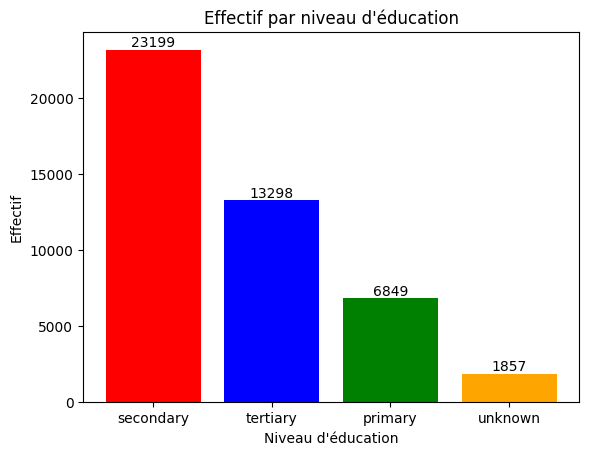

In [33]:
color= ["red", "blue", "green", "orange", "purple"]
plt.bar(effectif["education"],  effectif["count"], color=color )
# ajouter les values sur les barres
for i, v in enumerate(effectif["count"]):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')
plt.title("Effectif par niveau d'éducation")
plt.xlabel("Niveau d'éducation")
plt.ylabel("Effectif")
plt.show()

 Répartition visuelle des niveaux d’éducation :
Secondary (études secondaires) est la modalité la plus représentée avec 23 199 individus, soit plus de la moitié de l’échantillon.

Tertiary (études supérieures) arrive ensuite avec 13 298 individus, ce qui montre une proportion importante de personnes diplômées du supérieur.

Primary (études primaires) concerne 6 849 individus, soit une minorité.

Enfin, Unknown (niveau non renseigné) regroupe 1 857 individus, ce qui reste relativement faible.

Conclusion :
Le graphique confirme que la population étudiée est majoritairement instruite, avec une prédominance des niveaux secondaire et supérieur.
La faible proportion de données manquantes (unknown) indique une bonne qualité de la variable education.
Ce type de représentation est utile pour la segmentation ou pour analyser l’impact du niveau d’éducation sur des comportements (souscription, prêts, etc.).


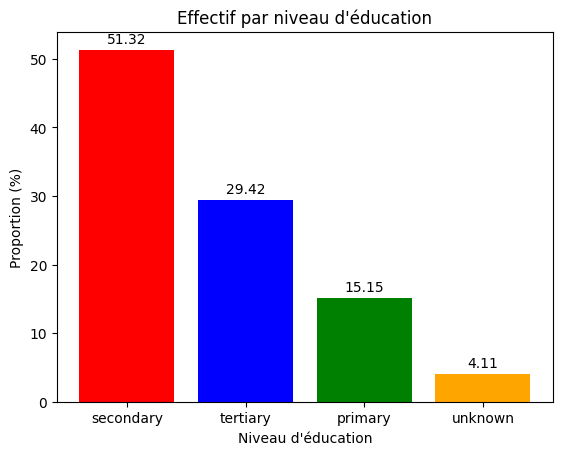

In [34]:
# Correction du calcul de la proportion (erreur de syntaxe : 100=... → à remplacer par 100 * ...)
effectif["proportion"] = round(100 * effectif["count"] / effectif["count"].sum(), 2)

# Création du graphique en barres
plt.bar(effectif["education"], effectif["proportion"], color=color)

# Ajout des valeurs sur les barres
for i, v in enumerate(effectif["proportion"]):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')

# Titres et étiquettes
plt.title("Effectif par niveau d'éducation")
plt.xlabel("Niveau d'éducation")
plt.ylabel("Proportion (%)")
plt.show()

Analyse :
Plus de la moitié des individus (51,32 %) ont un niveau d’éducation secondaire, ce qui en fait la modalité dominante.

Le niveau supérieur (tertiary) concerne près de 30 % des clients, révélant une population globalement instruite.

La catégorie primary reste minoritaire (15,15 %), tout comme unknown, qui représente une part négligeable (4,11 %).

Conclusion :
Ce graphique traduit visuellement la structure éducative de la population étudiée. L’importante proportion d’individus ayant un niveau secondaire ou supérieur confirme un profil globalement formé, cohérent avec une base de données marketing bancaire.
Ce type de répartition peut avoir un impact sur la réceptivité à certaines offres commerciales ou sur les taux de souscription.

### Analyses bivariées

/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7704/1412045988.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="y", y="duration", palette=color, data=df_majeur)
/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7704/1412045988.py:1: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.boxplot(x="y", y="duration", palette=color, data=df_majeur)


<Axes: xlabel='y', ylabel='duration'>

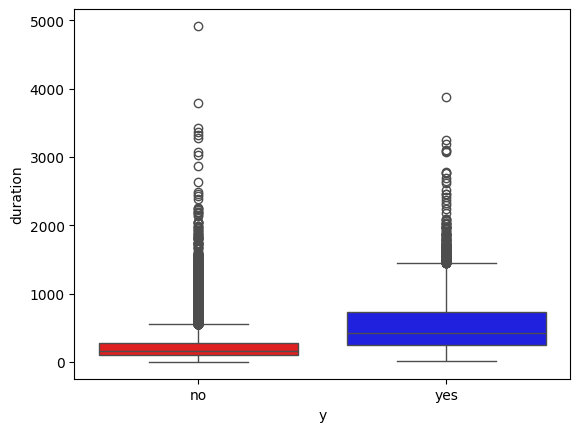

In [35]:
sns.boxplot(x="y", y="duration", palette=color, data=df_majeur)

Interprétation du graphique :
L’axe horizontal montre les deux modalités de la variable y :

no : le client n’a pas souscrit à l’offre.

yes : le client a souscrit.

L’axe vertical représente la durée de l’appel (duration) en secondes.

Durée moyenne des appels :

Les appels associés à une réponse "yes" sont nettement plus longs (boîte bleue), avec une médiane bien plus élevée.

En revanche, les appels pour lesquels la réponse est "no" sont en moyenne courts.

Présence d’outliers :

Dans les deux cas, on observe des valeurs extrêmes (plus de 3 000 secondes), mais elles sont plus nombreuses et plus dispersées dans le groupe "yes".

 Conclusion :
Ce graphique montre une corrélation forte entre la durée de l’appel et la probabilité de souscription.
Plus un appel dure longtemps, plus il est probable que le client accepte l’offre (y = yes).
Cela suggère que la durée de l’appel est un excellent indicateur d’intérêt, et pourrait être utile dans un modèle prédictif.



/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7704/771432754.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="y", y="age", palette=color, data=df_majeur)
/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7704/771432754.py:1: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.boxplot(x="y", y="age", palette=color, data=df_majeur)


<Axes: xlabel='y', ylabel='age'>

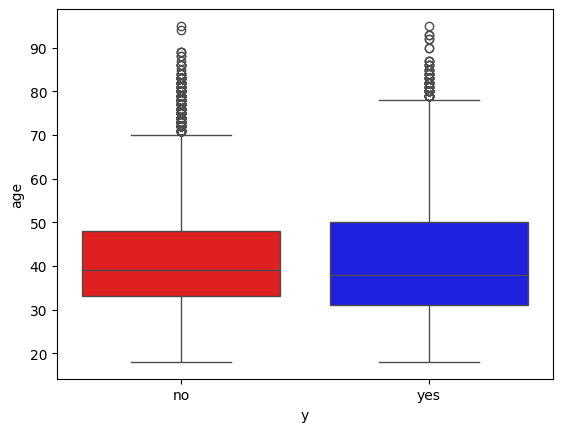

In [36]:
sns.boxplot(x="y", y="age", palette=color, data=df_majeur)

Interprétation du graphique :
Deux groupes sont comparés :

y = no : clients n’ayant pas souscrit (boîte rouge)

y = yes : clients ayant souscrit (boîte bleue)

Médiane de l’âge :

Les deux groupes ont une médiane assez proche (environ 38 ans pour les souscripteurs et 39 ans pour les non-souscripteurs), ce qui montre peu de différence centrale.

Dispersion :

Les deux groupes présentent une variabilité similaire, avec des âges compris majoritairement entre 30 et 50 ans.

Des outliers (valeurs atypiques) sont présents dans les deux cas au-delà de 70 ans.

Conclusion :
Contrairement à la variable duration, l’âge n’a pas de lien visuel fort avec la souscription. Les distributions sont très similaires entre les deux groupes, ce qui suggère que l’âge seul n’est probablement pas un facteur déterminant du comportement de souscription

In [37]:
table_contingence = pd.crosstab(df_majeur["y"], df_majeur["education"])
table_contingence

education,primary,secondary,tertiary,unknown
y,,,,
no,6258,20749,11302,1605
yes,591,2450,1996,252


Analyse :
Tous les niveaux d’éducation enregistrent des souscriptions (yes), mais avec des proportions très différentes.

Le taux de conversion (souscriptions par rapport au total) semble :

Plus élevé pour les niveaux tertiaire et unknown

Moins élevé pour les niveaux primary et secondary, en dépit de leurs effectifs plus élevés

Conclusion :
Même si le nombre brut de souscriptions est plus élevé chez les personnes ayant un niveau secondaire (2 450), cela s’explique surtout par leur grand effectif total.
Pour mesurer l’impact réel du niveau d’éducation sur la souscription, il serait pertinent de calculer les taux de souscription par niveau (ex. : yes / (yes + no)), afin d’identifier les profils les plus réceptifs.



/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7704/1496112247.py:1: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.countplot(x="y", hue="education", data=df_majeur, palette=color)


<Axes: xlabel='y', ylabel='count'>

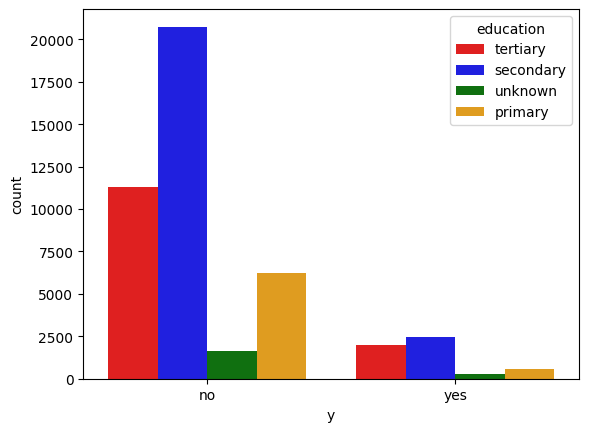

In [38]:
sns.countplot(x="y", hue="education", data=df_majeur, palette=color)

Lecture du graphique :
Ce graphique compare les effectifs de clients ayant ou non souscrit (y = yes ou no) pour chaque niveau d’éducation (hue="education") :

Pour y = no :

Les clients ayant un niveau secondary sont les plus nombreux, suivis par ceux de niveau tertiary.

Les niveaux primary et unknown apparaissent en moindre proportion.

Pour y = yes :

Bien que moins nombreux, on observe un rééquilibrage entre tertiary et secondary, voire un léger avantage du niveau tertiaire.

Les clients avec un niveau primary souscrivent beaucoup moins souvent que ceux avec un niveau supérieur.

Interprétation :
Même si les clients de niveau secondaire dominent en volume, ils ne sont pas forcément ceux qui souscrivent le plus.

La proportion de souscriptions semble plus élevée chez les clients de niveau tertiaire.

Les personnes avec un niveau primaire ou non renseigné sont les moins enclines à souscrire, en proportion.

 Conclusion :
Ce graphique met en évidence une relation entre le niveau d’éducation et la probabilité de souscription.
Pour valider cela statistiquement, on peut :

calculer les taux de conversion par niveau d’éducation,

ou effectuer un test du chi² sur la table de contingence.



In [39]:
prop_tabale = df_majeur.groupby("y")["education"].value_counts(normalize=True).reset_index(name='proportion')
prop_tabale

,y,education,proportion
0,no,secondary,0.519843
1,no,tertiary,0.283159
2,no,primary,0.156787
3,no,unknown,0.040211
4,yes,secondary,0.463226
5,yes,tertiary,0.377387
6,yes,primary,0.111741
7,yes,unknown,0.047646


 Interprétation :
Parmi les clients ayant souscrit (yes) :

Les niveaux secondary (46,3 %) et surtout tertiary (37,7 %) sont dominants.

Le niveau tertiary est proportionnellement plus représenté que chez les non-souscripteurs, ce qui suggère une meilleure réceptivité à l’offre.

Le niveau primary (11,2 %) est peu présent, indiquant une faible propension à souscrire.

Parmi les non-souscripteurs (no) :

La majorité vient du groupe secondary (52 %), mais cela reflète surtout sa forte représentation globale dans la base.

Conclusion :
Les clients avec un niveau tertiaire sont proportionnellement plus enclins à souscrire que les autres.
Ce tableau confirme que le niveau d’éducation est un facteur pertinent à prendre en compte dans une stratégie de ciblage marketing ou un modèle prédictif.

/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7704/206569462.py:1: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(x="y", y="proportion", hue="education", data=prop_tabale, palette=color)


<Axes: xlabel='y', ylabel='proportion'>

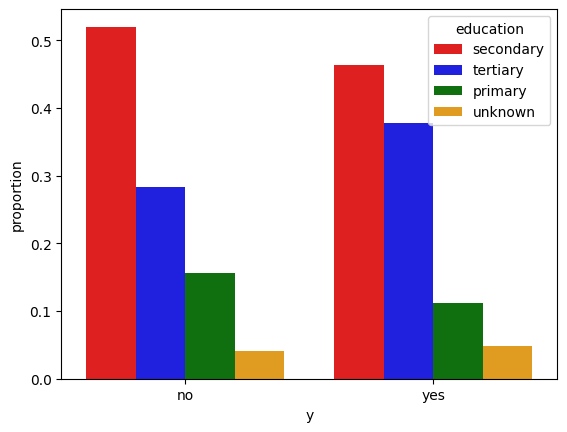

In [40]:
sns.barplot(x="y", y="proportion", hue="education", data=prop_tabale, palette=color)

Lecture du graphique :
Ce graphique affiche la répartition interne (en proportion) des niveaux d’éducation dans chaque groupe de réponse y :

À gauche (y = no) : parmi les non-souscripteurs

La majorité sont de niveau secondary (plus de 50 %)

Le niveau tertiary est moins représenté (~28 %)

Les niveaux primary et unknown sont minoritaires

À droite (y = yes) : parmi les souscripteurs

Le niveau secondary reste dominant, mais baisse légèrement (~46 %)

Le niveau tertiary augmente fortement (~38 %), indiquant une plus grande propension à souscrire

Le niveau primary est bien moins représenté (~11 %)

Conclusion :
Ce graphique confirme visuellement que :

Les individus ayant un niveau tertiaire sont plus susceptibles de souscrire.

Les personnes ayant un niveau primaire sont sous-représentées parmi les souscripteurs.

Le niveau d’éducation influence donc clairement la réponse à l’offre.

Ce type de visualisation est idéal pour identifier les profils les plus réceptifs, et peut guider une stratégie de ciblage marketing.

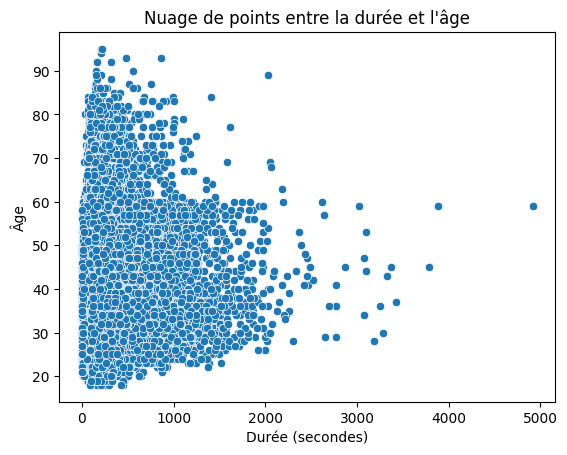

In [41]:
sns.scatterplot(x="duration", y="age", data=df_majeur)
plt.title("Nuage de points entre la durée et l'âge")
plt.xlabel("Durée (secondes)")
plt.ylabel("Âge")
plt.show()

 Lecture du graphique :
L’axe horizontal représente la durée de l’appel en secondes.

L’axe vertical représente l’âge des clients.

 Analyse :
La concentration des points est très élevée pour les appels de courte durée (moins de 1000 secondes), quel que soit l’âge.

Il n’existe pas de tendance claire entre l’âge et la durée des appels : les clients jeunes comme âgés peuvent avoir des appels courts ou longs.

Il y a cependant très peu de clients âgés (70+) avec des appels longs, ce qui pourrait indiquer une légère tendance à des communications plus brèves dans les tranches âgées — mais ce n’est pas marqué.

Les valeurs extrêmes (au-delà de 3000 secondes) sont rares et réparties sur tous les âges, sans schéma particulier.

 Conclusion :
Il n’y a pas de corrélation apparente entre l’âge du client et la durée de l’appel. Cela signifie que l’âge n’influence pas significativement la longueur des communications dans ce dataset.
Ce type de graphique est utile pour détecter des tendances ou corrélations, et ici, il confirme une dispersion homogène sans relation forte entre les deux variables.



In [42]:
df_quanti = df_majeur.select_dtypes(include=['int64', 'float64'])
df_quanti


,age,balance,day,duration,campaign,pdays,previous
0,58,2143.0,5,261,1,-1,0
1,44,29.0,5,151,1,-1,0
2,33,2.0,5,76,1,-1,0
3,47,1506.0,5,92,1,-1,0
4,33,1.0,5,198,1,-1,0
...,...,...,...,...,...,...,...
45206,51,825.0,17,977,3,-1,0
45207,71,1729.0,17,456,2,-1,0
45208,72,5715.0,17,1127,5,184,3
45209,57,668.0,17,508,4,-1,0


Sélection des variables quantitatives :
Le tableau df_quanti regroupe les colonnes numériques continues ou discrètes du dataset. Il contient 7 variables et 45 203 lignes (soit la totalité des clients majeurs).

Colonnes retenues :
age : âge du client

balance : solde bancaire

day : jour du mois du dernier contact

duration : durée de la dernière communication (en secondes)

campaign : nombre de contacts effectués lors de cette campagne

pdays : nombre de jours depuis le dernier contact précédent

previous : nombre de contacts effectués lors de campagnes précédentes

Conclusion :
Ces variables sont toutes de type numérique (int64 ou float64) et sont généralement utilisées pour :

des analyses statistiques descriptives,

des corrélations,

ou comme variables d'entrée dans un modèle prédictif.

In [43]:
mat_corr = df_quanti.corr()
mat_corr

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097827,-0.009113,-0.004639,0.004765,-0.023758,0.001290
balance,0.097827,1.000000,0.004350,0.021557,-0.014647,0.003387,0.016644
day,-0.009113,0.004350,1.000000,-0.030240,0.162388,-0.093154,-0.051776
duration,-0.004639,0.021557,-0.030240,1.000000,-0.084585,-0.001574,0.001197
campaign,0.004765,-0.014647,0.162388,-0.084585,1.000000,-0.088673,-0.032882
pdays,-0.023758,0.003387,-0.093154,-0.001574,-0.088673,1.000000,0.454811
previous,0.001290,0.016644,-0.051776,0.001197,-0.032882,0.454811,1.000000


 Interprétation des corrélations :
Les valeurs de cette matrice vont de -1 (corrélation parfaitement négative) à 1 (corrélation parfaitement positive). Une valeur proche de 0 indique peu ou pas de corrélation linéaire.

 Observations principales :
 previous et pdays → corrélation modérée (0.45)
➤ Plus un client a été contacté dans le passé, plus il y a de chances qu’un délai (pdays) ait été enregistré.

Toutes les autres variables présentent des corrélations très faibles (entre -0.1 et 0.1), ce qui indique :

Une indépendance relative entre ces variables.

Peu de relations linéaires fortes, par exemple :

age et balance : 0.09

duration et campaign : -0.08

age et duration : -0.004

Conclusion :
La matrice de corrélation montre que, à part pdays et previous, les variables quantitatives sont faiblement corrélées entre elles.
Cela peut être un avantage dans certains modèles (comme les forêts aléatoires) qui bénéficient de la diversité des variables. En revanche, cela limite l’usage de méthodes linéaires simples pour prédire une variable à partir d’une autre.

<Axes: >

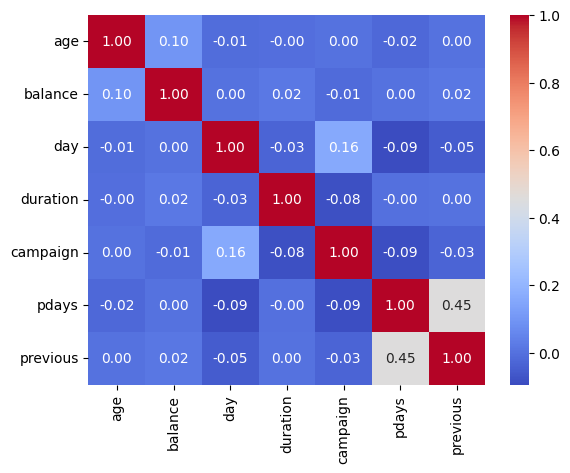

In [44]:
sns.heatmap(mat_corr, annot=True, cmap='coolwarm', fmt='.2f')

Interprétations clés :
pdays et previous : corrélation positive modérée (0.45)
➤ Les clients ayant été contactés récemment (pdays ≠ -1) ont souvent été contactés plusieurs fois auparavant.

 Toutes les autres corrélations sont très faibles (inférieures à 0.2 en valeur absolue) :

age et balance : 0.10

day et campaign : 0.16

duration et campaign : -0.08

Cela confirme qu’aucune variable quantitative n’est fortement redondante avec une autre — ce qui est positif pour éviter les effets de multicolinéarité dans des modèles linéaires.

 Conclusion :
La heatmap confirme visuellement que :

Le dataset est constitué de variables peu corrélées entre elles, ce qui est intéressant pour des modèles de machine learning.

Seul le lien pdays ↔ previous mérite d’être surveillé ou potentiellement traité (regroupement, sélection).

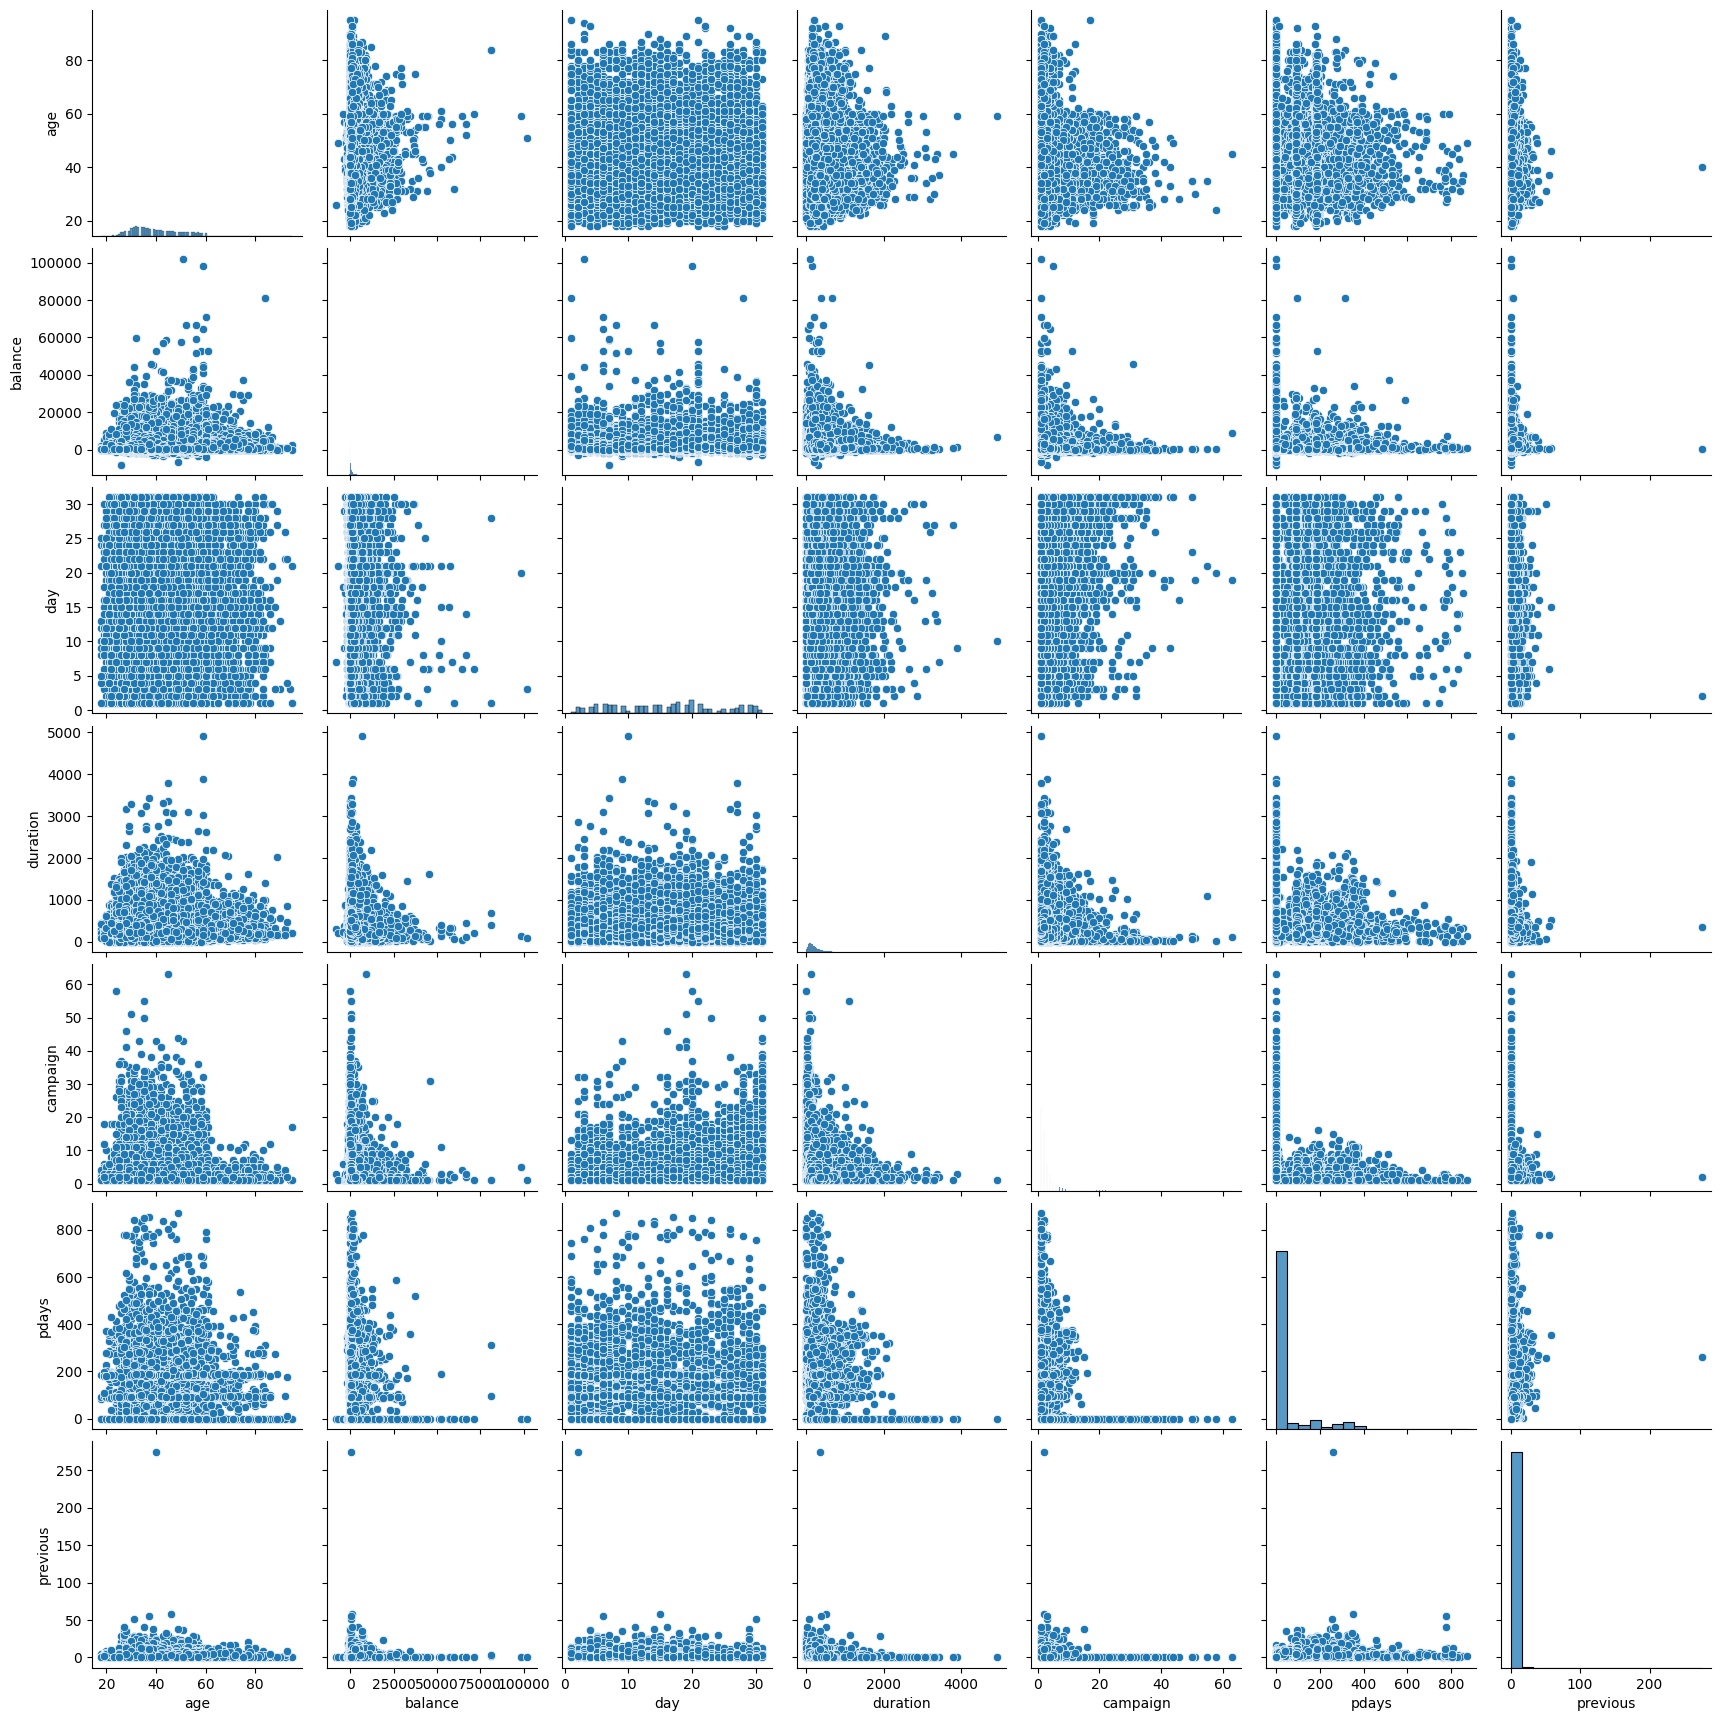

In [45]:
sns.pairplot(df_majeur)

La commande sns.pairplot(df_majeur) permet de générer une matrice de graphiques en nuages de points (scatter plots) pour toutes les paires de variables numériques du DataFrame df_majeur. Voici ce que cela fait en détail :

À quoi sert pairplot ?
Il affiche :

En diagonale : l’histogramme de chaque variable numérique (distribution).

En hors diagonale : les nuages de points entre chaque paire de variables.

Utilité de pairplot :
Repérer des relations entre variables (linéaires, non linéaires…).

Identifier des regroupements ou des patterns (par exemple, des clusters naturels).

Détecter des outliers (valeurs extrêmes visuellement isolées).

Explorer rapidement l’ensemble des variables numériques du jeu de données.

À savoir :
Si le dataset contient beaucoup de variables ou d’observations, la commande peut être lente ou produire une grille surchargée.

Il est souvent conseillé de l’appliquer seulement sur un sous-ensemble de variables (ex. : df_majeur[["age", "duration", "balance"]]) pour plus de lisibilité.



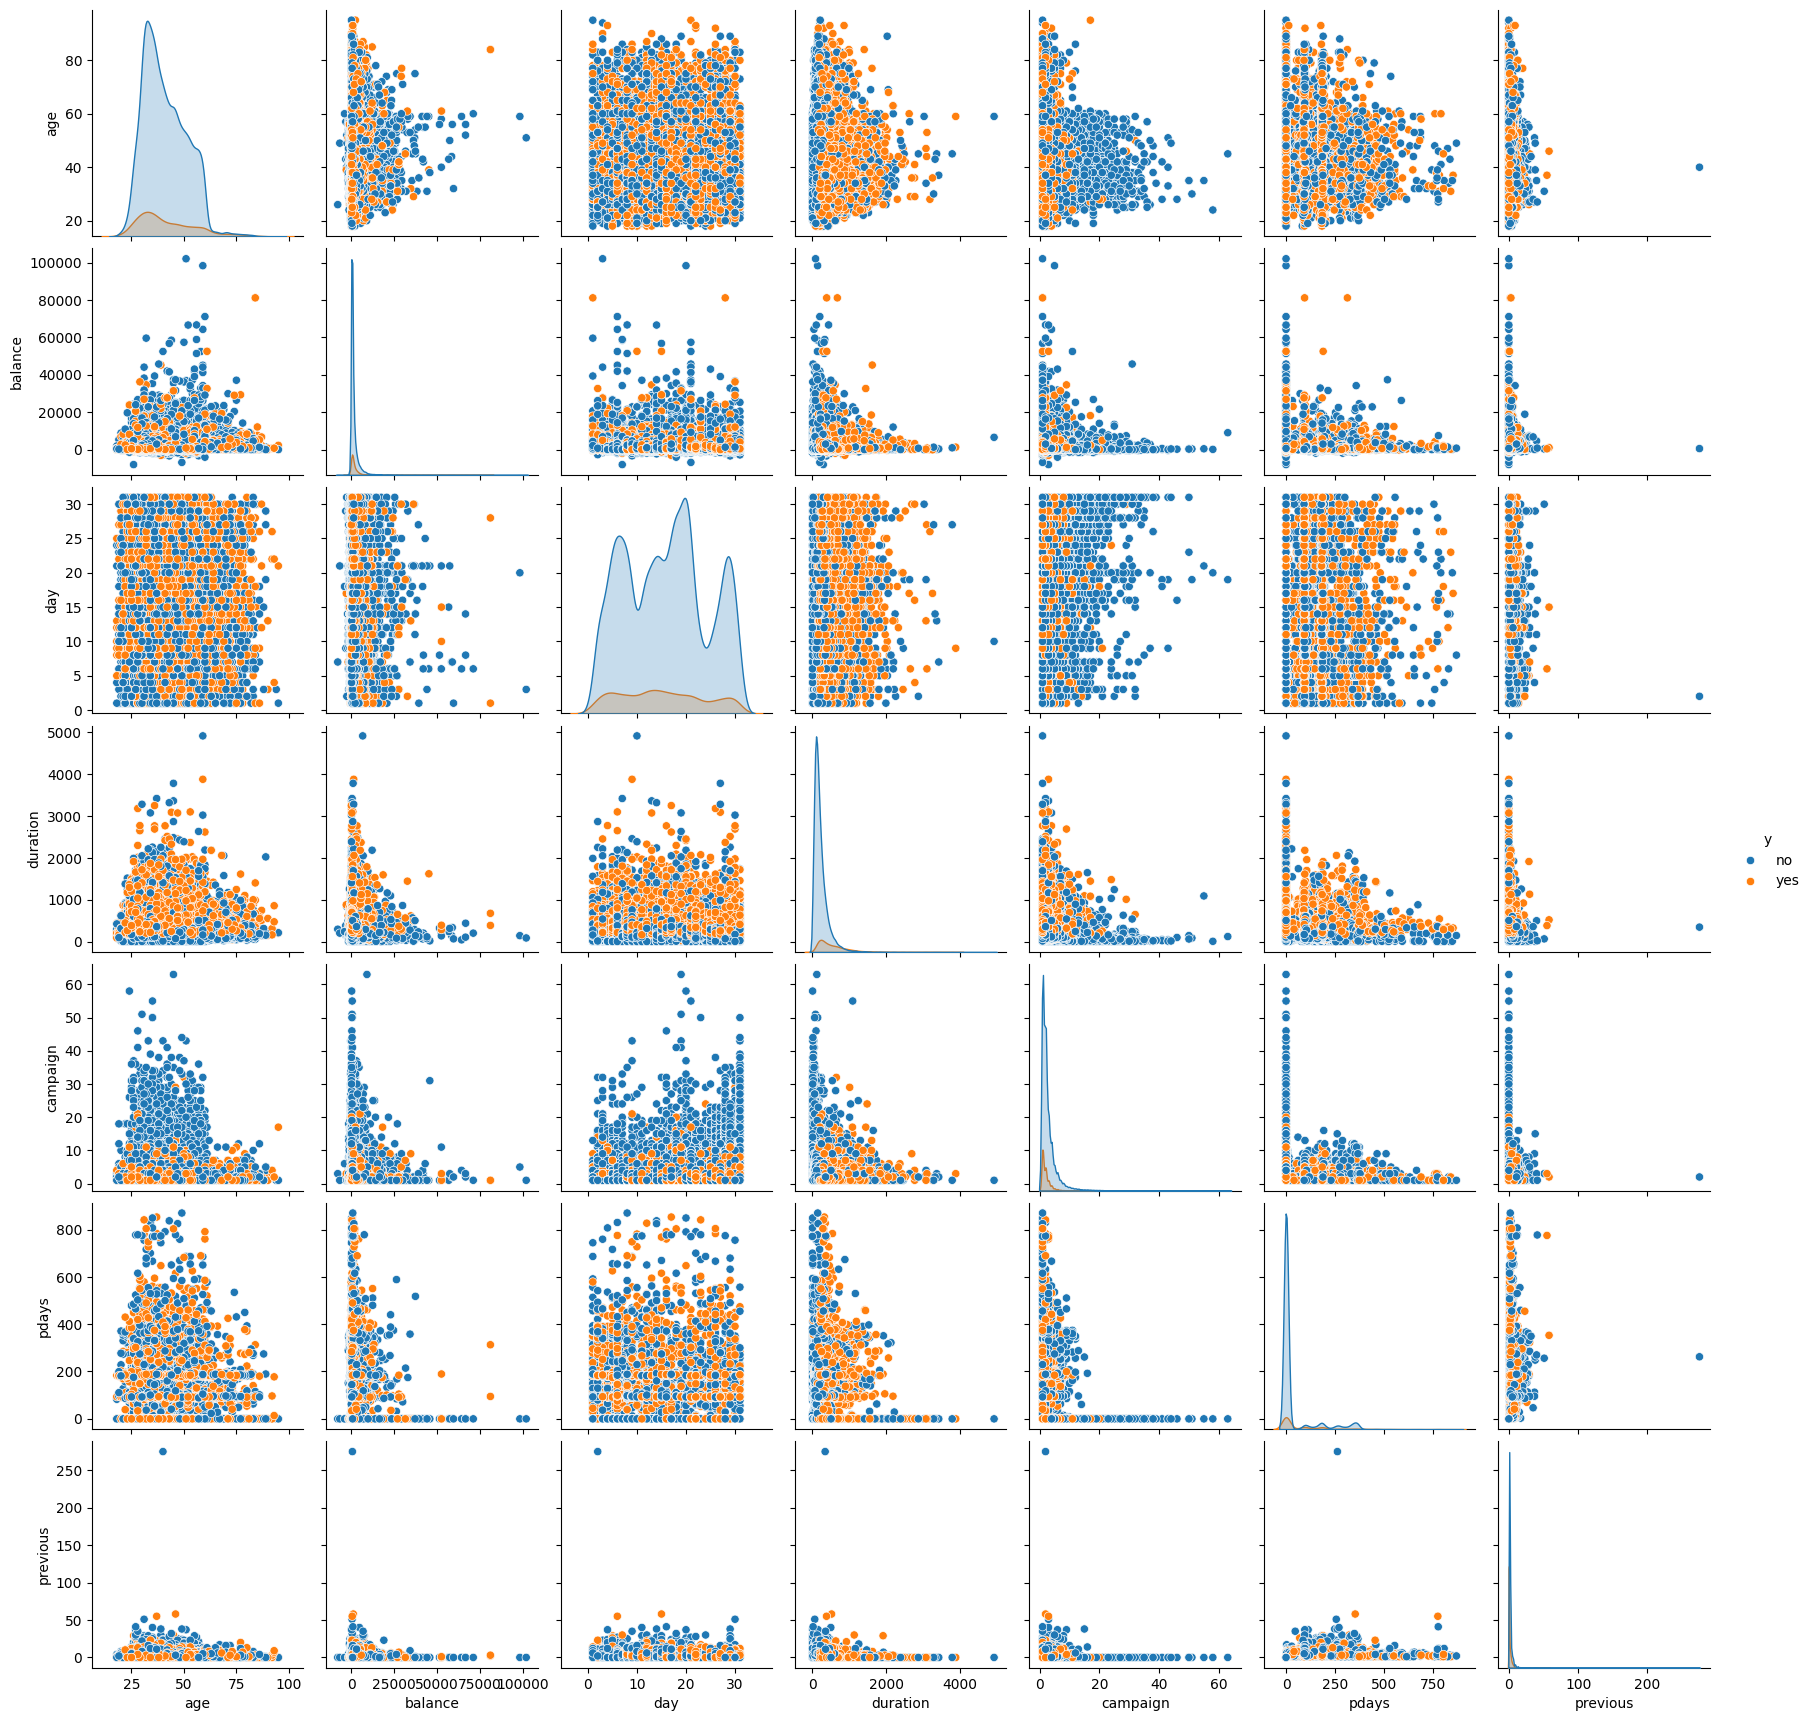

In [46]:
sns.pairplot(df_majeur, hue="y")

La commande sns.pairplot(df_majeur, hue="y") génère une matrice de graphiques croisés pour les variables numériques de df_majeur, en colorant les points selon la variable y, qui représente ici si le client a souscrit (yes) ou non (no) à l’offre.

 Que permet cette visualisation ?
En diagonale : histogrammes de chaque variable séparés selon y (par couleur).

En hors diagonale : nuages de points pour chaque paire de variables numériques, avec les points colorés selon y.

Cela permet de :

Repérer des zones où les classes se séparent (utile en classification),

Visualiser des corrélations conditionnelles à y,

Identifier des groupes de clients ayant un comportement distinct (souscripteurs vs non-souscripteurs).

Conclusion :
C’est une visualisation très utile pour détecter des schémas discriminants entre les deux classes (yes / no). Si les nuages de points montrent une séparation visible des couleurs dans certaines paires de variables, cela indique qu’un modèle prédictif pourra probablement bien les utiliser.

### Analyse des facteurs influençant la souscription à une offre bancaire suite à une campagne de téléprospection
Problématique

### quels sont les profils de clients les plus susceptibles de souscrire à une offre bancaire après un appel téléphonique ?

Réponse à la problématique

À partir de l’analyse exploratoire des données, plusieurs facteurs influencent la probabilité de souscription à une offre bancaire. Les résultats montrent que la souscription dépend davantage de facteurs comportementaux liés à la campagne que de caractéristiques socio-démographiques strictes.

### Facteurs clés identifiés
1. Durée de l’appel

La durée de l’appel est le facteur le plus déterminant de la souscription.

Les clients ayant souscrit présentent des appels significativement plus longs.

La majorité des appels courts (moins de 2 à 3 minutes) n’aboutissent pas à une souscription.

Les souscriptions apparaissent majoritairement lors d’appels dépassant plusieurs minutes.

### Interprétation :
Un appel long reflète un engagement réel du client et une interaction approfondie, augmentant fortement la probabilité de souscription.

2. Niveau d’éducation

Le niveau d’éducation joue un rôle important dans la réceptivité à l’offre.

Les clients de niveau tertiaire sont proportionnellement plus enclins à souscrire.

Le niveau secondary est majoritaire en volume, mais son taux de conversion est plus faible.

Les niveaux primary et unknown sont les moins réceptifs.

### Conclusion :
Un niveau d’éducation plus élevé est associé à une probabilité de souscription plus importante.

3. Historique de contact (previous / pdays)

Une corrélation positive modérée est observée entre le nombre de contacts passés (previous) et le délai depuis le dernier contact (pdays).

Les clients déjà contactés lors de campagnes précédentes semblent plus réceptifs.

### Interprétation :
La répétition des campagnes favorise la familiarité avec l’offre et améliore les chances de conversion.

4. Âge

La majorité des souscripteurs appartient à la tranche d’âge 25–50 ans.

Cependant, aucune corrélation linéaire forte n’est observée entre l’âge et la souscription.

Les distributions d’âge des souscripteurs et des non-souscripteurs sont proches.

### Conclusion :
L’âge n’est pas un facteur déterminant à lui seul, mais reste utile pour la segmentation marketing.

5. Solde bancaire (balance)

La distribution du solde bancaire est fortement asymétrique, avec de nombreux outliers.

Aucune relation significative directe n’est observée entre le solde et la souscription.

### Conclusion :
Le solde bancaire n’est pas un facteur explicatif majeur dans le cadre de cette campagne.

Profil type du client le plus susceptible de souscrire

Client adulte (25–50 ans), disposant d’un niveau d’éducation tertiaire, ayant déjà été contacté lors de campagnes précédentes, et engagé dans un appel téléphonique de durée relativement longue.

Implications business

Prioriser les clients à niveau d’éducation élevé lors des campagnes.

Favoriser des appels plus longs et qualitatifs grâce à des scripts adaptés.

Réactiver les clients ayant déjà été contactés.

Utiliser les variables comportementales comme leviers principaux d’optimisation des campagnes.

### CONCLUSION


Ce projet d’analyse bancaire nous a permis de mieux comprendre les comportements financiers des clients à travers une étude détaillée des données transactionnelles. En appliquant diverses techniques de traitement de données, de visualisation et d’analyse statistique, nous avons mis en évidence plusieurs tendances clés :

Les habitudes de dépenses varient fortement en fonction du type de client, du revenu mensuel et du profil d’utilisation.

Certaines anomalies et irrégularités ont pu être détectées, ouvrant la voie à des mécanismes de détection automatique pour la fraude ou les erreurs.

Des indicateurs de segmentation client ont été identifiés, facilitant la mise en place de stratégies de fidélisation ou d’offres ciblées.

Ce projet démontre la puissance de l’analyse de données dans un contexte bancaire et la manière dont elle peut appuyer la prise de décision stratégique. À l’avenir, cette démarche pourrait être enrichie par l'intégration de modèles de machine learning pour prédire les comportements clients ou optimiser les produits financiers proposés.